# Tổng hợp và tính điểm LLM-as-a-Judge

Notebook này nhận:

1. `llm_judge_mapping_secret.jsonl` được sinh khi chuẩn bị các batch ẩn danh.
2. Thư mục `llm_outputs_raw` chứa 20 file `batch_*_output.json` do LLM trả về.

Notebook sẽ:

- kiểm tra đầy đủ 20 batch, 200 mẫu và 800 candidate;
- giải mã A/B/C/D theo từng `batch_id` và `sample_id`;
- tính năm tiêu chí và `overall_score` theo trọng số đã chốt;
- tính bootstrap 95% CI theo `sample_id`;
- so sánh ghép cặp sáu cặp hệ thống;
- thống kê lỗi factual, phân bố điểm và số lần thắng;
- xuất CSV, JSONL, biểu đồ PNG, báo cáo kiểm tra và một file ZIP.

> Không tổng hợp trực tiếp theo A/B/C/D vì nhãn này được xáo trộn riêng cho từng mẫu. `has_major_factual_error` được báo cáo thành chỉ số riêng, không bị trừ thêm lần thứ hai vào `overall_score`.


## 1. Cấu hình

Chỉ cần sửa hai đường dẫn đầu vào trong cell dưới đây. Các tham số còn lại đã phù hợp với thiết kế 20 batch × 10 mẫu × 4 hệ thống.


In [1]:
from pathlib import Path

# ========================= ĐIỀN 2 ĐƯỜNG DẪN TẠI ĐÂY =========================
MAPPING_PATH = Path("/kaggle/input/datasets/tranducthinh2006/bn-nh-gi-200-mu-t-llm/llm_judge_mapping_secret.jsonl")
RAW_OUTPUT_DIR = Path("/kaggle/input/datasets/tranducthinh2006/bn-nh-gi-200-mu-t-llm/llm_outputs_raw")
# ============================================================================

OUTPUT_DIR = Path("/kaggle/working/llm_judge_analysis")
RAW_FILE_GLOB = "batch_*_output*.json"

EXPECTED_BATCHES = 20
EXPECTED_SAMPLES = 200
EXPECTED_SYSTEMS = ["lead1", "lead3", "scratch_transformer", "vit5"]
CANDIDATE_LABELS = ["A", "B", "C", "D"]

SYSTEM_DISPLAY_NAMES = {
    "lead1": "Lead-1",
    "lead3": "Lead-3",
    "scratch_transformer": "Scratch Transformer",
    "vit5": "ViT5",
}

SCORE_WEIGHTS = {
    "faithfulness": 0.35,
    "coverage": 0.25,
    "focus_relevance": 0.15,
    "coherence_fluency": 0.15,
    "conciseness_nonredundancy": 0.10,
}

N_BOOTSTRAP = 10_000
BOOTSTRAP_SEED = 42
CI_LEVEL = 0.95
ALLOW_OVERWRITE = True


## 2. Thư viện và hàm hỗ trợ

Notebook chỉ sử dụng các thư viện có sẵn trên Kaggle: Python chuẩn, NumPy, pandas và Matplotlib.


In [2]:
import hashlib
import json
import math
import os
import zipfile
from collections import Counter, defaultdict
from datetime import datetime, timezone
from itertools import combinations

# Dùng cache ghi được trên cả Kaggle và môi trường sandbox.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)

ALLOWED_ERROR_TYPES = {
    "ENTITY", "NUMBER", "DATE_TIME", "LOCATION", "PREDICATE", "RELATION",
    "CAUSALITY", "ATTRIBUTION", "NEGATION", "UNSUPPORTED", "OTHER",
}

SCORE_METRICS = list(SCORE_WEIGHTS.keys()) + ["overall_score"]
SUMMARY_METRICS = SCORE_METRICS + ["major_factual_error_rate"]


def require(condition, message):
    if not condition:
        raise ValueError(message)


def nonempty_string(value, *, context):
    require(isinstance(value, str) and value.strip(), f"{context}: phải là chuỗi không rỗng.")
    return value.strip()


def validate_score(value, *, context):
    require(
        not isinstance(value, bool) and isinstance(value, (int, float)),
        f"{context}: điểm phải là số, nhận được {value!r}.",
    )
    numeric = float(value)
    require(math.isfinite(numeric) and 1 <= numeric <= 5, f"{context}: điểm {value!r} nằm ngoài [1, 5].")
    return numeric


def read_jsonl(path):
    path = Path(path)
    require(path.is_file(), f"Không tìm thấy file: {path}")
    rows = []
    with path.open("r", encoding="utf-8-sig") as file:
        for line_no, raw_line in enumerate(file, start=1):
            if not raw_line.strip():
                continue
            try:
                row = json.loads(raw_line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"JSONL lỗi tại {path.name}, dòng {line_no}: {exc}") from exc
            require(isinstance(row, dict), f"{path.name}, dòng {line_no}: phải là JSON object.")
            rows.append((line_no, row))
    return rows


def load_json_object(path):
    # Đọc JSON thuần; chấp nhận thêm trường hợp LLM bọc bằng code fence.
    raw = Path(path).read_text(encoding="utf-8-sig").strip()
    was_code_fenced = False
    try:
        data = json.loads(raw)
    except json.JSONDecodeError as first_error:
        lines = raw.splitlines()
        if lines and lines[0].strip().lower() in {"```json", "```"} and lines[-1].strip() == "```":
            was_code_fenced = True
            candidate = "\n".join(lines[1:-1]).strip()
            try:
                data = json.loads(candidate)
            except json.JSONDecodeError as exc:
                raise ValueError(f"JSON không hợp lệ trong {Path(path).name}: {exc}") from exc
        else:
            raise ValueError(f"JSON không hợp lệ trong {Path(path).name}: {first_error}") from first_error
    require(isinstance(data, dict), f"{Path(path).name}: JSON cấp cao nhất phải là object.")
    return data, was_code_fenced


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def ensure_can_write(path):
    path = Path(path)
    if path.exists() and not ALLOW_OVERWRITE:
        raise FileExistsError(f"File đã tồn tại và ALLOW_OVERWRITE=False: {path}")
    path.parent.mkdir(parents=True, exist_ok=True)


def write_jsonl(path, records):
    ensure_can_write(path)
    with Path(path).open("w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")


def bootstrap_mean_ci(values, *, n_bootstrap, seed, ci_level):
    values = np.asarray(values, dtype=float)
    require(values.ndim == 1 and len(values) > 0, "Không có dữ liệu để bootstrap.")
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(n_bootstrap, len(values)))
    bootstrap_means = values[indices].mean(axis=1)
    alpha = (1.0 - ci_level) / 2.0
    low, high = np.quantile(bootstrap_means, [alpha, 1.0 - alpha])
    return float(low), float(high)


def paired_bootstrap_difference(values_a, values_b, *, n_bootstrap, seed, ci_level):
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)
    require(values_a.shape == values_b.shape and values_a.ndim == 1, "Hai dãy ghép cặp không cùng kích thước.")
    differences = values_a - values_b
    return bootstrap_mean_ci(
        differences,
        n_bootstrap=n_bootstrap,
        seed=seed,
        ci_level=ci_level,
    )


## 3. Đọc mapping và 20 file kết quả

Cell này thực hiện kiểm tra nghiêm ngặt. Nếu một batch thiếu candidate, trùng ID, sai thang điểm hoặc không khớp mapping, notebook sẽ dừng thay vì âm thầm tính kết quả sai.


In [3]:
require(MAPPING_PATH.is_file(), f"Không tìm thấy MAPPING_PATH: {MAPPING_PATH}")
require(RAW_OUTPUT_DIR.is_dir(), f"Không tìm thấy RAW_OUTPUT_DIR: {RAW_OUTPUT_DIR}")
require(len(EXPECTED_SYSTEMS) == len(CANDIDATE_LABELS) == 4, "Cần đúng bốn hệ thống và bốn nhãn A-D.")
require(abs(sum(SCORE_WEIGHTS.values()) - 1.0) < 1e-12, "Tổng SCORE_WEIGHTS phải bằng 1.0.")

# ----- Mapping bí mật -----
mapping_lookup = {}
mapping_sample_rows = set()
mapping_row_count = 0

for line_no, row in read_jsonl(MAPPING_PATH):
    batch_id = nonempty_string(row.get("batch_id"), context=f"Mapping dòng {line_no}, batch_id")
    sample_id = nonempty_string(row.get("sample_id"), context=f"Mapping dòng {line_no}, sample_id")
    candidate_to_system = row.get("candidate_to_system")
    require(isinstance(candidate_to_system, dict), f"Mapping dòng {line_no}: thiếu candidate_to_system object.")
    require(set(candidate_to_system) == set(CANDIDATE_LABELS), f"Mapping dòng {line_no}: phải có đúng A, B, C, D.")
    require(set(candidate_to_system.values()) == set(EXPECTED_SYSTEMS), f"Mapping dòng {line_no}: bốn system không đúng cấu hình.")

    sample_key = (batch_id, sample_id)
    require(sample_key not in mapping_sample_rows, f"Mapping bị trùng batch/sample: {sample_key}")
    mapping_sample_rows.add(sample_key)
    mapping_row_count += 1

    for candidate_id, system in candidate_to_system.items():
        key = (batch_id, sample_id, candidate_id)
        require(key not in mapping_lookup, f"Mapping bị trùng: {key}")
        mapping_lookup[key] = system

require(mapping_row_count == EXPECTED_SAMPLES, f"Mapping phải có {EXPECTED_SAMPLES} dòng, hiện có {mapping_row_count}.")

# ----- 20 output của LLM -----
raw_paths = sorted(RAW_OUTPUT_DIR.glob(RAW_FILE_GLOB))
require(
    len(raw_paths) == EXPECTED_BATCHES,
    f"Kỳ vọng {EXPECTED_BATCHES} file theo glob {RAW_FILE_GLOB!r}, tìm thấy {len(raw_paths)}: {[p.name for p in raw_paths]}",
)

expected_batch_ids = {f"batch_{index:02d}" for index in range(1, EXPECTED_BATCHES + 1)}
seen_batch_ids = set()
seen_sample_candidate = set()
sample_to_batches = defaultdict(set)
batch_result_counts = {}
used_mapping_keys = set()
decoded_records = []
code_fenced_files = []
unknown_error_types = set()
major_without_error_type = []

required_result_fields = {
    "sample_id", "candidate_id", "scores", "has_major_factual_error",
    "factual_error_types", "factual_error_evidence",
    "main_missing_information", "brief_reason",
}

for raw_path in raw_paths:
    data, was_code_fenced = load_json_object(raw_path)
    if was_code_fenced:
        code_fenced_files.append(raw_path.name)

    batch_id = nonempty_string(data.get("batch_id"), context=f"{raw_path.name}, batch_id")
    require(batch_id not in seen_batch_ids, f"Có nhiều file cùng batch_id={batch_id}.")
    seen_batch_ids.add(batch_id)

    results = data.get("results")
    require(isinstance(results, list), f"{raw_path.name}: results phải là list.")
    expected_per_batch = (EXPECTED_SAMPLES // EXPECTED_BATCHES) * len(EXPECTED_SYSTEMS)
    require(len(results) == expected_per_batch, f"{raw_path.name}: cần {expected_per_batch} results, có {len(results)}.")
    batch_result_counts[batch_id] = len(results)

    completeness = data.get("completeness")
    if completeness is not None:
        require(isinstance(completeness, dict), f"{raw_path.name}: completeness phải là object.")
        require(completeness.get("returned_candidates") == len(results), f"{raw_path.name}: returned_candidates không khớp.")
        require(completeness.get("missing") in ([], None), f"{raw_path.name}: LLM báo còn thiếu: {completeness.get('missing')}")

    local_pairs = set()
    for result_index, row in enumerate(results):
        context = f"{raw_path.name}, results[{result_index}]"
        require(isinstance(row, dict), f"{context}: phải là object.")
        missing_fields = required_result_fields - set(row)
        require(not missing_fields, f"{context}: thiếu trường {sorted(missing_fields)}.")

        sample_id = nonempty_string(row.get("sample_id"), context=f"{context}, sample_id")
        candidate_id = nonempty_string(row.get("candidate_id"), context=f"{context}, candidate_id").upper()
        require(candidate_id in CANDIDATE_LABELS, f"{context}: candidate_id={candidate_id!r} không hợp lệ.")

        local_pair = (sample_id, candidate_id)
        require(local_pair not in local_pairs, f"{raw_path.name}: trùng cặp {local_pair}.")
        local_pairs.add(local_pair)
        require(local_pair not in seen_sample_candidate, f"Cặp sample/candidate xuất hiện ở nhiều batch: {local_pair}.")
        seen_sample_candidate.add(local_pair)
        sample_to_batches[sample_id].add(batch_id)

        scores = row.get("scores")
        require(isinstance(scores, dict), f"{context}: scores phải là object.")
        normalized_scores = {
            metric: validate_score(scores.get(metric), context=f"{context}, scores.{metric}")
            for metric in SCORE_WEIGHTS
        }

        major = row.get("has_major_factual_error")
        require(isinstance(major, bool), f"{context}: has_major_factual_error phải là boolean.")

        error_types = row.get("factual_error_types")
        require(isinstance(error_types, list), f"{context}: factual_error_types phải là list.")
        normalized_error_types = []
        for error_type in error_types:
            normalized = nonempty_string(error_type, context=f"{context}, factual_error_types").upper()
            if normalized not in normalized_error_types:
                normalized_error_types.append(normalized)
            if normalized not in ALLOWED_ERROR_TYPES:
                unknown_error_types.add(normalized)
        if major and not normalized_error_types:
            major_without_error_type.append((batch_id, sample_id, candidate_id))

        for text_field in ["factual_error_evidence", "main_missing_information", "brief_reason"]:
            require(isinstance(row.get(text_field), str), f"{context}: {text_field} phải là chuỗi.")

        mapping_key = (batch_id, sample_id, candidate_id)
        require(mapping_key in mapping_lookup, f"Không tìm thấy mapping cho {mapping_key}.")
        used_mapping_keys.add(mapping_key)
        system = mapping_lookup[mapping_key]

        overall_score = sum(normalized_scores[metric] * weight for metric, weight in SCORE_WEIGHTS.items())
        decoded_records.append({
            "batch_id": batch_id,
            "source_file": raw_path.name,
            "sample_id": sample_id,
            "candidate_id": candidate_id,
            "system": system,
            **normalized_scores,
            "overall_score": float(overall_score),
            "has_major_factual_error": major,
            "factual_error_types": normalized_error_types,
            "factual_error_evidence": row["factual_error_evidence"],
            "main_missing_information": row["main_missing_information"],
            "brief_reason": row["brief_reason"],
        })

# ----- Kiểm tra toàn cục -----
require(seen_batch_ids == expected_batch_ids, f"Batch ID thiếu/thừa: expected={sorted(expected_batch_ids)}, actual={sorted(seen_batch_ids)}")
require(len(decoded_records) == EXPECTED_SAMPLES * len(EXPECTED_SYSTEMS), f"Cần 800 kết quả, có {len(decoded_records)}.")
require(len(sample_to_batches) == EXPECTED_SAMPLES, f"Cần {EXPECTED_SAMPLES} sample_id, có {len(sample_to_batches)}.")
require(all(len(batch_ids) == 1 for batch_ids in sample_to_batches.values()), "Có sample_id xuất hiện trong nhiều batch.")
require(used_mapping_keys == set(mapping_lookup), "Mapping và kết quả LLM không khớp hoàn toàn; có mapping thừa hoặc kết quả thiếu.")

decoded_df = pd.DataFrame(decoded_records).sort_values(["sample_id", "system"]).reset_index(drop=True)

for sample_id, group in decoded_df.groupby("sample_id"):
    require(set(group["candidate_id"]) == set(CANDIDATE_LABELS), f"{sample_id}: không đủ A-D.")
    require(set(group["system"]) == set(EXPECTED_SYSTEMS), f"{sample_id}: không đủ bốn hệ thống.")

system_counts = decoded_df["system"].value_counts().to_dict()
require(all(system_counts.get(system) == EXPECTED_SAMPLES for system in EXPECTED_SYSTEMS), f"Số kết quả mỗi hệ thống không đúng: {system_counts}")

position_table = pd.crosstab(decoded_df["candidate_id"], decoded_df["system"]).reindex(
    index=CANDIDATE_LABELS, columns=EXPECTED_SYSTEMS, fill_value=0
)
expected_per_position = EXPECTED_SAMPLES // len(EXPECTED_SYSTEMS)
require((position_table.to_numpy() == expected_per_position).all(), f"Vị trí A-D không cân bằng:\n{position_table}")

print("KIỂM TRA DỮ LIỆU THÀNH CÔNG")
print(f"- Batch: {len(seen_batch_ids)}")
print(f"- Sample: {decoded_df['sample_id'].nunique()}")
print(f"- Candidate: {len(decoded_df)}")
print(f"- Mỗi system: {system_counts}")
print("- Bảng cân bằng vị trí A-D:")
display(position_table)

if code_fenced_files:
    print(f"Cảnh báo: {len(code_fenced_files)} file được bọc bằng markdown code fence và đã được xử lý: {code_fenced_files}")
if unknown_error_types:
    print(f"Cảnh báo: loại lỗi ngoài danh sách chuẩn: {sorted(unknown_error_types)}")
if major_without_error_type:
    print(f"Cảnh báo: {len(major_without_error_type)} dòng major=True nhưng factual_error_types rỗng.")

display(decoded_df.head(8))


KIỂM TRA DỮ LIỆU THÀNH CÔNG
- Batch: 20
- Sample: 200
- Candidate: 800
- Mỗi system: {'lead1': 200, 'lead3': 200, 'scratch_transformer': 200, 'vit5': 200}
- Bảng cân bằng vị trí A-D:


system,lead1,lead3,scratch_transformer,vit5
candidate_id,,,,
A,50,50,50,50
B,50,50,50,50
C,50,50,50,50
D,50,50,50,50


,batch_id,source_file,sample_id,candidate_id,system,faithfulness,coverage,focus_relevance,coherence_fluency,conciseness_nonredundancy,overall_score,has_major_factual_error,factual_error_types,factual_error_evidence,main_missing_information,brief_reason
0,batch_01,batch_01_output.json,test_000174,D,lead1,5.0,2.0,5.0,5.0,4.0,4.15,False,[],,"Sự quan tâm và các đề nghị của Thủ tướng, phản...","Câu chính xác, rõ và đúng trọng tâm mở đầu, nh..."
1,batch_01,batch_01_output.json,test_000174,B,lead3,5.0,3.0,5.0,5.0,4.0,4.40,False,[],,"Các đề nghị hỗ trợ, tôn trọng luật pháp và giữ...","Hoàn toàn đúng và tập trung vào lời chúc, sự g..."
2,batch_01,batch_01_output.json,test_000174,C,scratch_transformer,4.0,3.0,4.0,3.0,3.0,3.50,False,"[RELATION, ATTRIBUTION]",Chuỗi “các tỉnh hội... nỗ lực cho con em” nhập...,"Nguyện vọng về địa vị pháp lý, yêu cầu tôn trọ...","Bao quát vài ý lớn nhưng dồn vào một câu dài, ..."
3,batch_01,batch_01_output.json,test_000174,A,vit5,2.0,1.0,3.0,5.0,5.0,2.65,True,"[DATE_TIME, PREDICATE, UNSUPPORTED]",Candidate nêu “Ngày 15-2 (mùng 6 Tết Kỷ Hợi)” ...,"Lời chúc Tết, các đề nghị hỗ trợ cộng đồng, ph...","Câu gọn, rõ nhưng dựng thêm ngày và hành động ..."
4,batch_01,batch_01_output.json,test_000371,C,lead1,5.0,2.0,5.0,5.0,4.0,4.15,False,[],,"Các biểu hiện, nguyên nhân, thời gian kéo dài,...","Khẳng định mở đầu chính xác và đúng chủ đề, so..."
5,batch_01,batch_01_output.json,test_000371,B,lead3,5.0,2.0,4.0,5.0,4.0,4.00,False,[],,"Nguyên nhân miễn dịch và tinh thần, thời gian ...","Thông tin hoàn toàn đúng và dễ hiểu, nhưng chỉ..."
6,batch_01,batch_01_output.json,test_000371,D,scratch_transformer,3.0,1.0,2.0,5.0,4.0,2.75,True,"[ATTRIBUTION, UNSUPPORTED]",SOURCE có nêu COVID-19 ảnh hưởng sức khỏe tinh...,"Trọng tâm mệt mỏi do COVID-19: biểu hiện, cơ c...","Mệnh đề về sức khỏe tinh thần có cơ sở, nhưng ..."
7,batch_01,batch_01_output.json,test_000371,A,vit5,3.0,1.0,2.0,4.0,5.0,2.70,True,"[CAUSALITY, UNSUPPORTED]",Candidate gắn phản ứng miễn dịch quá mức với “...,"Bối cảnh mệt mỏi do COVID-19, triệu chứng đi k...",Nêu được cơ chế miễn dịch và nhu cầu nghỉ ngơi...


## 4. Xuất dữ liệu đã giải mã

`llm_judge_results_decoded.jsonl` giữ nguyên danh sách loại lỗi. Bản CSV chuyển danh sách này thành chuỗi phân tách bằng `|` để dễ mở bằng Excel hoặc pandas.


In [4]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DECODED_JSONL_PATH = OUTPUT_DIR / "llm_judge_results_decoded.jsonl"
DECODED_CSV_PATH = OUTPUT_DIR / "llm_judge_results_decoded.csv"

write_jsonl(DECODED_JSONL_PATH, decoded_records)

decoded_csv_df = decoded_df.copy()
decoded_csv_df["factual_error_types"] = decoded_csv_df["factual_error_types"].apply(lambda values: "|".join(values))
ensure_can_write(DECODED_CSV_PATH)
decoded_csv_df.to_csv(DECODED_CSV_PATH, index=False, encoding="utf-8-sig")

output_files = [DECODED_JSONL_PATH, DECODED_CSV_PATH]
print(f"Đã xuất {len(decoded_df)} dòng dữ liệu đã giải mã.")


Đã xuất 800 dòng dữ liệu đã giải mã.


## 5. Điểm trung bình và bootstrap 95% CI

Với mỗi hệ thống, notebook báo cáo riêng năm tiêu chí, `overall_score` và tỷ lệ lỗi factual nghiêm trọng. Khoảng tin cậy được bootstrap trên 200 `sample_id`.


In [5]:
metric_summary_rows = []
seed_offset = 0

for system in EXPECTED_SYSTEMS:
    system_df = decoded_df[decoded_df["system"] == system].sort_values("sample_id")
    require(len(system_df) == EXPECTED_SAMPLES, f"{system}: thiếu mẫu khi tổng hợp.")

    for metric in SCORE_METRICS:
        values = system_df[metric].to_numpy(dtype=float)
        ci_low, ci_high = bootstrap_mean_ci(
            values,
            n_bootstrap=N_BOOTSTRAP,
            seed=BOOTSTRAP_SEED + seed_offset,
            ci_level=CI_LEVEL,
        )
        seed_offset += 1
        metric_summary_rows.append({
            "system": system,
            "system_display": SYSTEM_DISPLAY_NAMES[system],
            "metric": metric,
            "n": len(values),
            "mean": float(values.mean()),
            "median": float(np.median(values)),
            "std": float(values.std(ddof=1)),
            "ci_level": CI_LEVEL,
            "ci_low": ci_low,
            "ci_high": ci_high,
        })

    major_values = system_df["has_major_factual_error"].astype(float).to_numpy()
    ci_low, ci_high = bootstrap_mean_ci(
        major_values,
        n_bootstrap=N_BOOTSTRAP,
        seed=BOOTSTRAP_SEED + seed_offset,
        ci_level=CI_LEVEL,
    )
    seed_offset += 1
    metric_summary_rows.append({
        "system": system,
        "system_display": SYSTEM_DISPLAY_NAMES[system],
        "metric": "major_factual_error_rate",
        "n": len(major_values),
        "mean": float(major_values.mean()),
        "median": float(np.median(major_values)),
        "std": float(major_values.std(ddof=1)),
        "ci_level": CI_LEVEL,
        "ci_low": ci_low,
        "ci_high": ci_high,
    })

metric_summary_df = pd.DataFrame(metric_summary_rows)

compact_rows = []
for system in EXPECTED_SYSTEMS:
    system_summary = metric_summary_df[metric_summary_df["system"] == system].set_index("metric")
    row = {
        "system": system,
        "system_display": SYSTEM_DISPLAY_NAMES[system],
        "n": EXPECTED_SAMPLES,
        "major_factual_error_count": int(
            decoded_df.loc[decoded_df["system"] == system, "has_major_factual_error"].sum()
        ),
    }
    for metric in SUMMARY_METRICS:
        row[f"{metric}_mean"] = float(system_summary.loc[metric, "mean"])
        row[f"{metric}_ci_low"] = float(system_summary.loc[metric, "ci_low"])
        row[f"{metric}_ci_high"] = float(system_summary.loc[metric, "ci_high"])
    compact_rows.append(row)

summary_by_system_df = pd.DataFrame(compact_rows)

METRIC_SUMMARY_PATH = OUTPUT_DIR / "llm_judge_metric_summary_long.csv"
SUMMARY_BY_SYSTEM_PATH = OUTPUT_DIR / "llm_judge_summary_by_system.csv"
ensure_can_write(METRIC_SUMMARY_PATH)
ensure_can_write(SUMMARY_BY_SYSTEM_PATH)
metric_summary_df.to_csv(METRIC_SUMMARY_PATH, index=False, encoding="utf-8-sig")
summary_by_system_df.to_csv(SUMMARY_BY_SYSTEM_PATH, index=False, encoding="utf-8-sig")
output_files.extend([METRIC_SUMMARY_PATH, SUMMARY_BY_SYSTEM_PATH])

display_table = pd.DataFrame({"Hệ thống": [SYSTEM_DISPLAY_NAMES[s] for s in EXPECTED_SYSTEMS]})
for metric in SCORE_METRICS:
    values = []
    for system in EXPECTED_SYSTEMS:
        row = metric_summary_df[(metric_summary_df["system"] == system) & (metric_summary_df["metric"] == metric)].iloc[0]
        values.append(f"{row['mean']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]")
    display_table[metric] = values

major_values = []
for system in EXPECTED_SYSTEMS:
    row = metric_summary_df[
        (metric_summary_df["system"] == system)
        & (metric_summary_df["metric"] == "major_factual_error_rate")
    ].iloc[0]
    major_values.append(f"{100*row['mean']:.1f}% [{100*row['ci_low']:.1f}%, {100*row['ci_high']:.1f}%]")
display_table["major_factual_error"] = major_values

print("Giá trị hiển thị: mean [bootstrap 95% CI]")
display(display_table)


Giá trị hiển thị: mean [bootstrap 95% CI]


,Hệ thống,faithfulness,coverage,focus_relevance,coherence_fluency,conciseness_nonredundancy,overall_score,major_factual_error
0,Lead-1,"4.995 [4.985, 5.000]","2.420 [2.305, 2.540]","4.060 [3.900, 4.215]","4.710 [4.620, 4.795]","4.245 [4.115, 4.365]","4.093 [4.028, 4.156]","0.0% [0.0%, 0.0%]"
1,Lead-3,"5.000 [5.000, 5.000]","3.415 [3.305, 3.525]","4.145 [4.045, 4.245]","4.630 [4.540, 4.720]","3.995 [3.900, 4.090]","4.320 [4.268, 4.369]","0.0% [0.0%, 0.0%]"
2,Scratch Transformer,"3.385 [3.170, 3.600]","2.155 [2.035, 2.275]","3.620 [3.435, 3.800]","4.095 [3.930, 4.260]","4.470 [4.370, 4.565]","3.328 [3.186, 3.463]","45.5% [39.0%, 52.5%]"
3,ViT5,"3.255 [3.045, 3.465]","2.220 [2.095, 2.350]","3.810 [3.640, 3.975]","4.340 [4.205, 4.475]","4.625 [4.525, 4.715]","3.379 [3.250, 3.510]","52.0% [45.0%, 59.0%]"


## 6. Phân bố điểm, loại lỗi và số lần thắng

Tỷ lệ loại lỗi được tính theo số prediction có chứa loại lỗi đó chia cho 200 prediction của hệ thống. Một prediction có thể chứa nhiều loại lỗi nên tổng các tỷ lệ không bắt buộc bằng 100%.


In [6]:
# Phân bố điểm 1-5 của năm tiêu chí
distribution_rows = []
for system in EXPECTED_SYSTEMS:
    system_df = decoded_df[decoded_df["system"] == system]
    for metric in SCORE_WEIGHTS:
        counts = system_df[metric].value_counts().to_dict()
        for score in range(1, 6):
            count = int(counts.get(float(score), 0))
            distribution_rows.append({
                "system": system,
                "system_display": SYSTEM_DISPLAY_NAMES[system],
                "metric": metric,
                "score": score,
                "count": count,
                "proportion": count / EXPECTED_SAMPLES,
            })
score_distribution_df = pd.DataFrame(distribution_rows)

# Tỷ lệ loại lỗi
observed_error_types = sorted(
    ALLOWED_ERROR_TYPES
    | {error_type for values in decoded_df["factual_error_types"] for error_type in values}
)
error_type_rows = []
for system in EXPECTED_SYSTEMS:
    system_df = decoded_df[decoded_df["system"] == system]
    for error_type in observed_error_types:
        count = int(system_df["factual_error_types"].apply(lambda values: error_type in values).sum())
        error_type_rows.append({
            "system": system,
            "system_display": SYSTEM_DISPLAY_NAMES[system],
            "error_type": error_type,
            "prediction_count": count,
            "prediction_rate": count / EXPECTED_SAMPLES,
        })
error_types_df = pd.DataFrame(error_type_rows)

# Thắng theo overall_score; nếu hòa, mỗi hệ thống nhận 1/k điểm thắng phân số
overall_pivot = decoded_df.pivot(index="sample_id", columns="system", values="overall_score").reindex(columns=EXPECTED_SYSTEMS)
require(not overall_pivot.isna().any().any(), "Thiếu overall_score trong bảng ghép cặp.")
win_stats = {system: {"unique_wins": 0, "tie_involvements": 0, "fractional_win_credit": 0.0} for system in EXPECTED_SYSTEMS}

for _, row in overall_pivot.iterrows():
    best = float(row.max())
    winners = [system for system in EXPECTED_SYSTEMS if np.isclose(row[system], best, atol=1e-12)]
    for system in winners:
        win_stats[system]["fractional_win_credit"] += 1.0 / len(winners)
        if len(winners) == 1:
            win_stats[system]["unique_wins"] += 1
        else:
            win_stats[system]["tie_involvements"] += 1

system_wins_df = pd.DataFrame([
    {
        "system": system,
        "system_display": SYSTEM_DISPLAY_NAMES[system],
        **win_stats[system],
        "fractional_win_rate": win_stats[system]["fractional_win_credit"] / EXPECTED_SAMPLES,
    }
    for system in EXPECTED_SYSTEMS
])

SCORE_DISTRIBUTION_PATH = OUTPUT_DIR / "llm_judge_score_distribution.csv"
ERROR_TYPES_PATH = OUTPUT_DIR / "llm_judge_error_types.csv"
SYSTEM_WINS_PATH = OUTPUT_DIR / "llm_judge_system_wins.csv"
for frame, path in [
    (score_distribution_df, SCORE_DISTRIBUTION_PATH),
    (error_types_df, ERROR_TYPES_PATH),
    (system_wins_df, SYSTEM_WINS_PATH),
]:
    ensure_can_write(path)
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    output_files.append(path)

display(system_wins_df)


,system,system_display,unique_wins,tie_involvements,fractional_win_credit,fractional_win_rate
0,lead1,Lead-1,30,35,46.583333,0.232917
1,lead3,Lead-3,90,31,104.416667,0.522083
2,scratch_transformer,Scratch Transformer,11,16,18.250000,0.091250
3,vit5,ViT5,25,13,30.750000,0.153750


## 7. So sánh ghép cặp giữa các hệ thống

Mỗi chênh lệch được tính trên cùng 200 `sample_id`. Với sáu điểm số, giá trị cao hơn tốt hơn. Với `major_factual_error_rate`, giá trị thấp hơn tốt hơn.

Nếu bootstrap CI của chênh lệch A − B không chứa 0, cột `ci_conclusion` cho biết hệ thống nào được ủng hộ bởi dữ liệu.


In [7]:
pairwise_rows = []
seed_offset = 10_000

pairwise_metric_sources = {
    **{metric: metric for metric in SCORE_METRICS},
    "major_factual_error_rate": "has_major_factual_error",
}

for metric_name, source_column in pairwise_metric_sources.items():
    pivot = decoded_df.pivot(index="sample_id", columns="system", values=source_column).reindex(columns=EXPECTED_SYSTEMS)
    require(len(pivot) == EXPECTED_SAMPLES and not pivot.isna().any().any(), f"Không thể tạo bảng ghép cặp cho {metric_name}.")
    higher_is_better = metric_name != "major_factual_error_rate"

    for system_a, system_b in combinations(EXPECTED_SYSTEMS, 2):
        values_a = pivot[system_a].astype(float).to_numpy()
        values_b = pivot[system_b].astype(float).to_numpy()
        differences = values_a - values_b
        ci_low, ci_high = paired_bootstrap_difference(
            values_a,
            values_b,
            n_bootstrap=N_BOOTSTRAP,
            seed=BOOTSTRAP_SEED + seed_offset,
            ci_level=CI_LEVEL,
        )
        seed_offset += 1

        equal = np.isclose(values_a, values_b, atol=1e-12)
        if higher_is_better:
            wins_a = int((values_a > values_b).sum())
            wins_b = int((values_b > values_a).sum())
            if ci_low > 0:
                conclusion = f"favors_{system_a}"
            elif ci_high < 0:
                conclusion = f"favors_{system_b}"
            else:
                conclusion = "inconclusive"
        else:
            wins_a = int((values_a < values_b).sum())
            wins_b = int((values_b < values_a).sum())
            if ci_high < 0:
                conclusion = f"favors_{system_a}"
            elif ci_low > 0:
                conclusion = f"favors_{system_b}"
            else:
                conclusion = "inconclusive"

        pairwise_rows.append({
            "system_a": system_a,
            "system_a_display": SYSTEM_DISPLAY_NAMES[system_a],
            "system_b": system_b,
            "system_b_display": SYSTEM_DISPLAY_NAMES[system_b],
            "metric": metric_name,
            "higher_is_better": higher_is_better,
            "n_paired_samples": len(values_a),
            "mean_a": float(values_a.mean()),
            "mean_b": float(values_b.mean()),
            "mean_difference_a_minus_b": float(differences.mean()),
            "ci_level": CI_LEVEL,
            "difference_ci_low": ci_low,
            "difference_ci_high": ci_high,
            "wins_a": wins_a,
            "ties": int(equal.sum()),
            "wins_b": wins_b,
            "win_rate_a_excluding_ties": wins_a / max(1, wins_a + wins_b),
            "ci_conclusion": conclusion,
        })

pairwise_df = pd.DataFrame(pairwise_rows)
PAIRWISE_PATH = OUTPUT_DIR / "llm_judge_pairwise_comparison.csv"
ensure_can_write(PAIRWISE_PATH)
pairwise_df.to_csv(PAIRWISE_PATH, index=False, encoding="utf-8-sig")
output_files.append(PAIRWISE_PATH)

print("So sánh ghép cặp theo overall_score:")
display(
    pairwise_df[pairwise_df["metric"] == "overall_score"][
        [
            "system_a_display", "system_b_display", "mean_a", "mean_b",
            "mean_difference_a_minus_b", "difference_ci_low", "difference_ci_high",
            "wins_a", "ties", "wins_b", "ci_conclusion",
        ]
    ].reset_index(drop=True)
)


So sánh ghép cặp theo overall_score:


,system_a_display,system_b_display,mean_a,mean_b,mean_difference_a_minus_b,difference_ci_low,difference_ci_high,wins_a,ties,wins_b,ci_conclusion
0,Lead-1,Lead-3,4.09325,4.31950,-0.22625,-0.288500,-0.167750,49,28,123,favors_lead3
1,Lead-1,Scratch Transformer,4.09325,3.32775,0.76550,0.613494,0.920000,136,20,44,favors_lead1
2,Lead-1,ViT5,4.09325,3.37925,0.71400,0.574250,0.851000,144,14,42,favors_lead1
3,Lead-3,Scratch Transformer,4.31950,3.32775,0.99175,0.850994,1.133500,162,12,26,favors_lead3
4,Lead-3,ViT5,4.31950,3.37925,0.94025,0.806244,1.084762,158,7,35,favors_lead3
5,Scratch Transformer,ViT5,3.32775,3.37925,-0.05150,-0.229250,0.124756,91,12,98,inconclusive


## 8. Biểu đồ dùng cho báo cáo

Các biểu đồ được lưu dưới dạng PNG độ phân giải cao trong thư mục output.


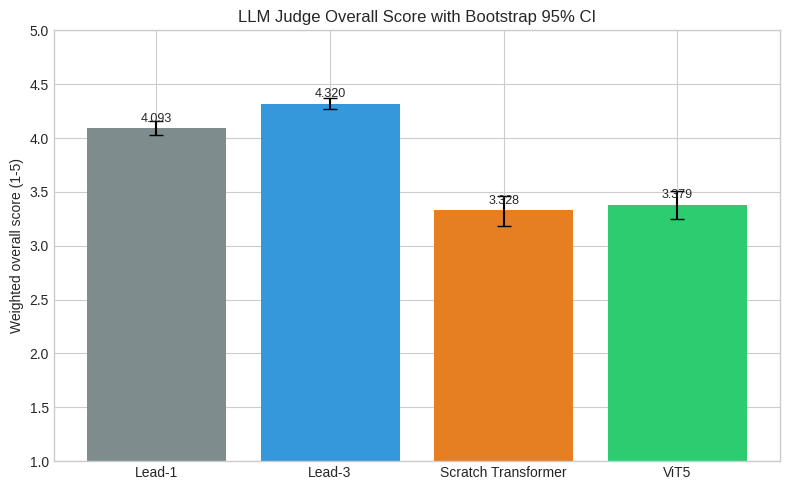

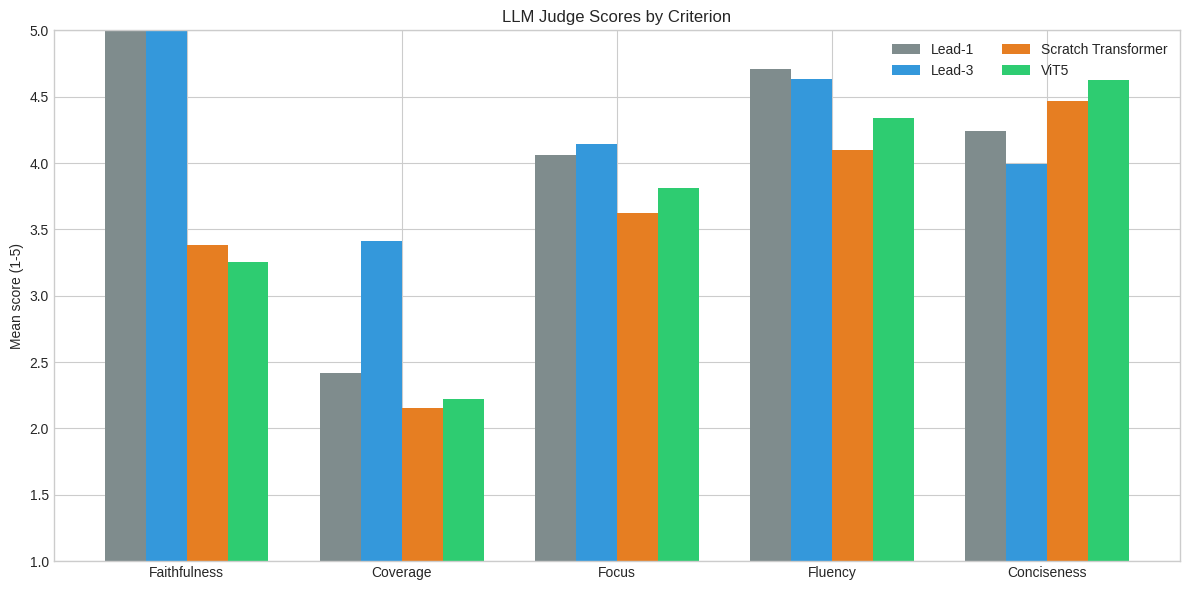

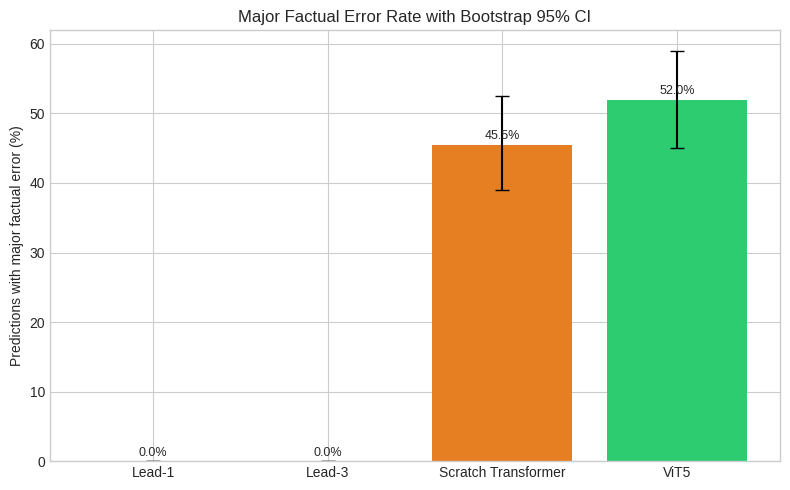

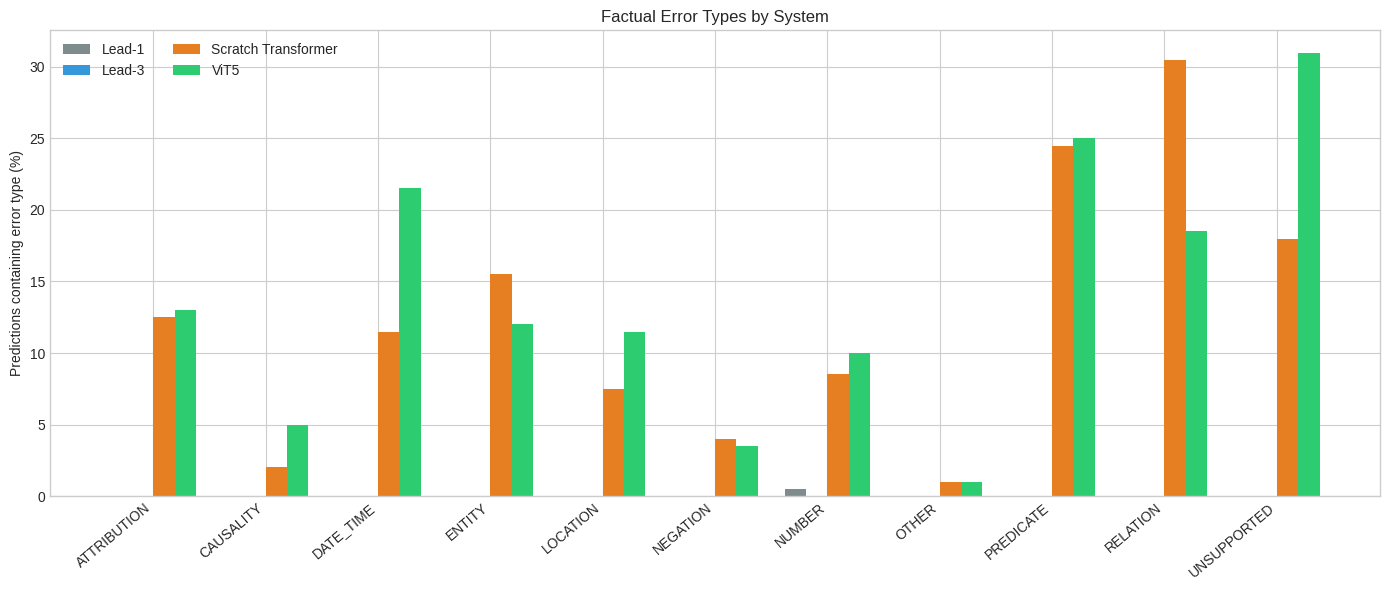

In [8]:
plt.style.use("seaborn-v0_8-whitegrid")
colors = {
    "lead1": "#7f8c8d",
    "lead3": "#3498db",
    "scratch_transformer": "#e67e22",
    "vit5": "#2ecc71",
}

# 1. Overall score với 95% CI
overall_rows = metric_summary_df[metric_summary_df["metric"] == "overall_score"].set_index("system").loc[EXPECTED_SYSTEMS]
x = np.arange(len(EXPECTED_SYSTEMS))
means = overall_rows["mean"].to_numpy()
yerr = np.vstack([
    means - overall_rows["ci_low"].to_numpy(),
    overall_rows["ci_high"].to_numpy() - means,
])
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, means, color=[colors[s] for s in EXPECTED_SYSTEMS], yerr=yerr, capsize=5)
ax.set_xticks(x, [SYSTEM_DISPLAY_NAMES[s] for s in EXPECTED_SYSTEMS])
ax.set_ylabel("Weighted overall score (1-5)")
ax.set_ylim(1, 5)
ax.set_title("LLM Judge Overall Score with Bootstrap 95% CI")
for index, value in enumerate(means):
    ax.text(index, value + 0.06, f"{value:.3f}", ha="center", fontsize=9)
fig.tight_layout()
OVERALL_CHART_PATH = OUTPUT_DIR / "overall_score_ci.png"
fig.savefig(OVERALL_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 2. Điểm trung bình theo năm tiêu chí
criteria = list(SCORE_WEIGHTS.keys())
criteria_labels = ["Faithfulness", "Coverage", "Focus", "Fluency", "Conciseness"]
x = np.arange(len(criteria))
width = 0.19
fig, ax = plt.subplots(figsize=(12, 6))
for index, system in enumerate(EXPECTED_SYSTEMS):
    values = [
        metric_summary_df[
            (metric_summary_df["system"] == system) & (metric_summary_df["metric"] == metric)
        ]["mean"].iloc[0]
        for metric in criteria
    ]
    ax.bar(x + (index - 1.5) * width, values, width, label=SYSTEM_DISPLAY_NAMES[system], color=colors[system])
ax.set_xticks(x, criteria_labels)
ax.set_ylabel("Mean score (1-5)")
ax.set_ylim(1, 5)
ax.set_title("LLM Judge Scores by Criterion")
ax.legend(ncol=2)
fig.tight_layout()
CRITERIA_CHART_PATH = OUTPUT_DIR / "criteria_mean_scores.png"
fig.savefig(CRITERIA_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 3. Tỷ lệ lỗi factual nghiêm trọng với 95% CI
major_rows = metric_summary_df[
    metric_summary_df["metric"] == "major_factual_error_rate"
].set_index("system").loc[EXPECTED_SYSTEMS]
means = major_rows["mean"].to_numpy() * 100
yerr = np.vstack([
    means - major_rows["ci_low"].to_numpy() * 100,
    major_rows["ci_high"].to_numpy() * 100 - means,
])
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(np.arange(4), means, color=[colors[s] for s in EXPECTED_SYSTEMS], yerr=yerr, capsize=5)
ax.set_xticks(np.arange(4), [SYSTEM_DISPLAY_NAMES[s] for s in EXPECTED_SYSTEMS])
ax.set_ylabel("Predictions with major factual error (%)")
ax.set_ylim(bottom=0)
ax.set_title("Major Factual Error Rate with Bootstrap 95% CI")
for index, value in enumerate(means):
    ax.text(index, value + 0.8, f"{value:.1f}%", ha="center", fontsize=9)
fig.tight_layout()
MAJOR_CHART_PATH = OUTPUT_DIR / "major_factual_error_rate.png"
fig.savefig(MAJOR_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

# 4. Tỷ lệ từng loại lỗi
error_pivot = error_types_df.pivot(index="error_type", columns="system", values="prediction_rate").reindex(columns=EXPECTED_SYSTEMS)
x = np.arange(len(error_pivot.index))
fig, ax = plt.subplots(figsize=(14, 6))
for index, system in enumerate(EXPECTED_SYSTEMS):
    ax.bar(
        x + (index - 1.5) * width,
        error_pivot[system].to_numpy() * 100,
        width,
        label=SYSTEM_DISPLAY_NAMES[system],
        color=colors[system],
    )
ax.set_xticks(x, error_pivot.index, rotation=40, ha="right")
ax.set_ylabel("Predictions containing error type (%)")
ax.set_title("Factual Error Types by System")
ax.legend(ncol=2)
fig.tight_layout()
ERROR_CHART_PATH = OUTPUT_DIR / "factual_error_types.png"
fig.savefig(ERROR_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

output_files.extend([
    OVERALL_CHART_PATH,
    CRITERIA_CHART_PATH,
    MAJOR_CHART_PATH,
    ERROR_CHART_PATH,
])


## 9. Báo cáo kiểm tra và đóng gói kết quả

ZIP cuối chứa toàn bộ bảng và biểu đồ, nhưng không chứa các file raw hay mapping bí mật.


In [9]:
QUALITY_REPORT_PATH = OUTPUT_DIR / "llm_judge_quality_check.json"
ZIP_PATH = OUTPUT_DIR / "llm_judge_analysis_outputs.zip"

quality_report = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "validation_status": "passed",
    "configuration": {
        "expected_batches": EXPECTED_BATCHES,
        "expected_samples": EXPECTED_SAMPLES,
        "expected_systems": EXPECTED_SYSTEMS,
        "score_weights": SCORE_WEIGHTS,
        "n_bootstrap": N_BOOTSTRAP,
        "bootstrap_seed": BOOTSTRAP_SEED,
        "ci_level": CI_LEVEL,
    },
    "input_integrity": {
        "mapping_file": {
            "filename": MAPPING_PATH.name,
            "sha256": sha256_file(MAPPING_PATH),
            "rows": mapping_row_count,
        },
        "raw_output_files": [
            {"filename": path.name, "sha256": sha256_file(path)} for path in raw_paths
        ],
    },
    "counts": {
        "batches": len(seen_batch_ids),
        "samples": int(decoded_df["sample_id"].nunique()),
        "candidates": len(decoded_df),
        "per_system": {key: int(value) for key, value in system_counts.items()},
        "per_batch": {key: int(value) for key, value in sorted(batch_result_counts.items())},
    },
    "candidate_position_counts": {
        label: {system: int(position_table.loc[label, system]) for system in EXPECTED_SYSTEMS}
        for label in CANDIDATE_LABELS
    },
    "warnings": {
        "code_fenced_files": code_fenced_files,
        "unknown_error_types": sorted(unknown_error_types),
        "major_true_but_error_types_empty_count": len(major_without_error_type),
        "major_true_but_error_types_empty_examples": major_without_error_type[:20],
    },
    "output_files": [path.name for path in output_files],
}

ensure_can_write(QUALITY_REPORT_PATH)
QUALITY_REPORT_PATH.write_text(
    json.dumps(quality_report, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
output_files.append(QUALITY_REPORT_PATH)

ensure_can_write(ZIP_PATH)
with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(set(output_files), key=lambda item: item.name):
        archive.write(path, arcname=path.name)

print("HOÀN TẤT")
print(f"- Thư mục kết quả: {OUTPUT_DIR}")
print(f"- File ZIP để tải: {ZIP_PATH}")
print("- Các bảng quan trọng nhất:")
print(f"  1. {SUMMARY_BY_SYSTEM_PATH.name}")
print(f"  2. {PAIRWISE_PATH.name}")
print(f"  3. {ERROR_TYPES_PATH.name}")
print(f"  4. {DECODED_JSONL_PATH.name}")


HOÀN TẤT
- Thư mục kết quả: /kaggle/working/llm_judge_analysis
- File ZIP để tải: /kaggle/working/llm_judge_analysis/llm_judge_analysis_outputs.zip
- Các bảng quan trọng nhất:
  1. llm_judge_summary_by_system.csv
  2. llm_judge_pairwise_comparison.csv
  3. llm_judge_error_types.csv
  4. llm_judge_results_decoded.jsonl


## Cách đọc kết quả

- `llm_judge_summary_by_system.csv`: bảng chính để đưa vào báo cáo.
- `llm_judge_pairwise_comparison.csv`: kiểm tra chênh lệch giữa từng cặp hệ thống trên cùng 200 mẫu.
- `llm_judge_error_types.csv`: phân tích hệ thống thường mắc loại lỗi factual nào.
- `llm_judge_system_wins.csv`: số lần đứng đầu theo `overall_score`; đây là chỉ số bổ sung, không thay thế điểm từng tiêu chí.
- `llm_judge_results_decoded.jsonl`: dữ liệu 800 prediction đã giải mã để phân tích định tính.
- `llm_judge_quality_check.json`: bằng chứng rằng dữ liệu đầu vào đầy đủ và việc ghép mapping thành công.

Không nên kết luận chỉ từ `overall_score`. Trong báo cáo, luôn trình bày riêng năm tiêu chí và tỷ lệ lỗi factual nghiêm trọng. Với bảng ghép cặp, nếu CI chứa 0 thì ghi nhận rằng dữ liệu chưa cho thấy chênh lệch rõ ràng, không khẳng định hai hệ thống hoàn toàn tương đương.
